# Species Recognition Model Analysis
Two models will be compared for species recognition : **DINO** and **YOLO-cls**. 

In [ ]:
import os
import pickle
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import torchvision.transforms as T
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

# Use tqdm.notebook for cleaner progress bars in Jupyter
from tqdm.notebook import tqdm 

# Ensure plots render inline
%matplotlib inline

In [3]:
# --- CONFIGURATION ---
DINO_TRAIN_DIR = r"C:\Users\Work Mode Big Dog\OneDrive - ECAM\Bureau\ERASMUS\PROJECT\CODE\data\processed\UMT\classification\UMT+Fish4Knowledge\train" 
CUSTOM_IMAGES = r"C:\Users\Work Mode Big Dog\OneDrive - ECAM\Bureau\ERASMUS\PROJECT\CODE\data\processed\UMT\classification\UMT For Validation\Images"
CUSTOM_LABELS = r"C:\Users\Work Mode Big Dog\OneDrive - ECAM\Bureau\ERASMUS\PROJECT\CODE\data\processed\UMT\classification\UMT For Validation\updated-labels-with-species"

TARGET_SPECIES = [
    "Dascyllus_reticulatus", 
    "Hemigymnus_melapterus", 
    "Pomacentrus_moluccensis", 
    "Abudefduf_vaigiensis", 
    "Scaridae"
]

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")

Using device: cpu


In [4]:
# --- LOAD DINOv2 ---
print(f"Loading DINOv2 on {DEVICE}...")
dinov2 = torch.hub.load('facebookresearch/dinov2', 'dinov2_vits14').to(DEVICE)
dinov2.eval()

# --- TRANSFORMS ---
train_transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

inference_transform = T.Compose([
    T.ToPILImage(),
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

def get_dino_embeddings(model, transform, image_rgb, device):
    """Passes a single cropped image through DINO to get the 384-d vector."""
    img_tensor = transform(image_rgb).unsqueeze(0).to(device)
    with torch.no_grad():
        embedding = model(img_tensor)
    return embedding.cpu().numpy()

Loading DINOv2 on cpu...


Using cache found in C:\Users\Work Mode Big Dog/.cache\torch\hub\facebookresearch_dinov2_main
C:\Users\Work Mode Big Dog/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
C:\Users\Work Mode Big Dog/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
C:\Users\Work Mode Big Dog/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


In [5]:
# 1. Extract Embeddings from the Original DINO Train set
print("Extracting foundation embeddings from Training set...")
train_dataset = ImageFolder(root=DINO_TRAIN_DIR, transform=train_transform)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=False)

X_train, y_train = [], []
with torch.no_grad():
    for images, targets in tqdm(train_loader, desc="Extracting Features"):
        features = dinov2(images.to(DEVICE))
        X_train.append(features.cpu().numpy())
        y_train.append(targets.numpy())
        
X_train = np.vstack(X_train)
y_train = np.concatenate(y_train)
database_classes = train_dataset.classes

Extracting foundation embeddings from Training set...


Extracting Features:   0%|          | 0/862 [00:00<?, ?it/s]

In [6]:
# 2. Train the Linear Classifier 
print("\nTraining Balanced Linear Classifier...")
clf = LogisticRegression(class_weight='balanced', max_iter=1000)
clf.fit(X_train, y_train)
print("Classifier trained successfully!")


Training Balanced Linear Classifier...
Classifier trained successfully!


In [ ]:
# 1. Force Python to create the folder if it doesn't exist yet
os.makedirs('weights/classification', exist_ok=True)

# 2. Package the model and the class list together
model_data = {'clf': clf, 'classes': database_classes}
with open('weights/classification/dino_classifier.pkl', 'wb') as f:
    pickle.dump(model_data, f)
    
print("Successfully saved classifier to weights/classification/dino_classifier.pkl")

Successfully saved classifier to weights/classification/dino_classifier.pkl


In [ ]:
# 3. Run Inference ONLY on Targets in the Custom Dataset
print("Running Inference on Custom Bounding Boxes...")
y_true, y_pred = [], []
correct_images, incorrect_images = [], [] 

# --- FAILSAFE 1: Track missing files ---
missing_images = [] 

for label_file in tqdm(os.listdir(CUSTOM_LABELS)):
    if not label_file.endswith('.txt'): continue
    
    img_path = os.path.join(CUSTOM_IMAGES, label_file.replace('.txt', '.jpg'))
    
    # --- FAILSAFE 2: Check if file physically exists ---
    if not os.path.exists(img_path): 
        missing_images.append(label_file.replace('.txt', ''))
        continue
        
    img = cv2.imread(img_path)
    
    # --- FAILSAFE 3: Check if file is corrupted/unreadable ---
    if img is None:
        missing_images.append(label_file.replace('.txt', '') + " (Unreadable)")
        continue
        
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w, _ = img.shape
    
    with open(os.path.join(CUSTOM_LABELS, label_file), 'r') as f:
        lines = f.readlines()
        
    for line in lines:
        parts = line.strip().split()
        if len(parts) < 5: continue # Failsafe for empty or malformed lines
        
        true_species = parts[0]
        
        # STRICT FILTER: Only evaluate if the label is one of our 5 targets
        if true_species not in TARGET_SPECIES: 
            continue
        
        cx, cy, bw, bh = map(float, parts[1:5])
        x1 = int((cx - bw/2) * w)
        y1 = int((cy - bh/2) * h)
        x2 = int((cx + bw/2) * w)
        y2 = int((cy + bh/2) * h)
        
        crop = img_rgb[max(0, y1):min(h, y2), max(0, x1):min(w, x2)]
        
        # Failsafe for out-of-bounds bounding boxes resulting in 0px crops
        if crop.size == 0: continue 
            
        # Use the inference_transform for the OpenCV crop
        emb = get_dino_embeddings(dinov2, inference_transform, crop, DEVICE)
        pred_idx = clf.predict(emb)[0]
        pred_species = database_classes[pred_idx]
        
        y_true.append(true_species)
        y_pred.append(pred_species)
        
        vis_data = (crop, true_species, pred_species)
        if true_species == pred_species and len(correct_images) < 9:
            correct_images.append(vis_data)
        elif true_species != pred_species and len(incorrect_images) < 9:
            incorrect_images.append(vis_data)
            
print(f"Processed {len(y_true)} target crops successfully.")

# --- FAILSAFE REPORTING ---
if missing_images:
    print(f"\n WARNING: Skipped {len(missing_images)} label files due to missing or unreadable images.")
    # Uncomment the line below if you want to see exactly which files are missing
    # print(f"Missing/Skipped files: {missing_images[:10]} ...")

Running Inference on Custom Bounding Boxes...


  0%|          | 0/209 [00:00<?, ?it/s]

Processed 324 target crops successfully.



TARGET SPECIES CLASSIFICATION REPORT (LINEAR PROBE)
                         precision    recall  f1-score   support

   Abudefduf_vaigiensis       0.75      0.75      0.75         4
  Dascyllus_reticulatus       0.86      0.80      0.83        96
  Hemigymnus_melapterus       1.00      0.40      0.57         5
                 Others       0.00      0.00      0.00         0
Pomacentrus_moluccensis       0.86      0.89      0.88       147
               Scaridae       0.97      0.85      0.90        72

               accuracy                           0.85       324
              macro avg       0.74      0.62      0.65       324
           weighted avg       0.88      0.85      0.86       324



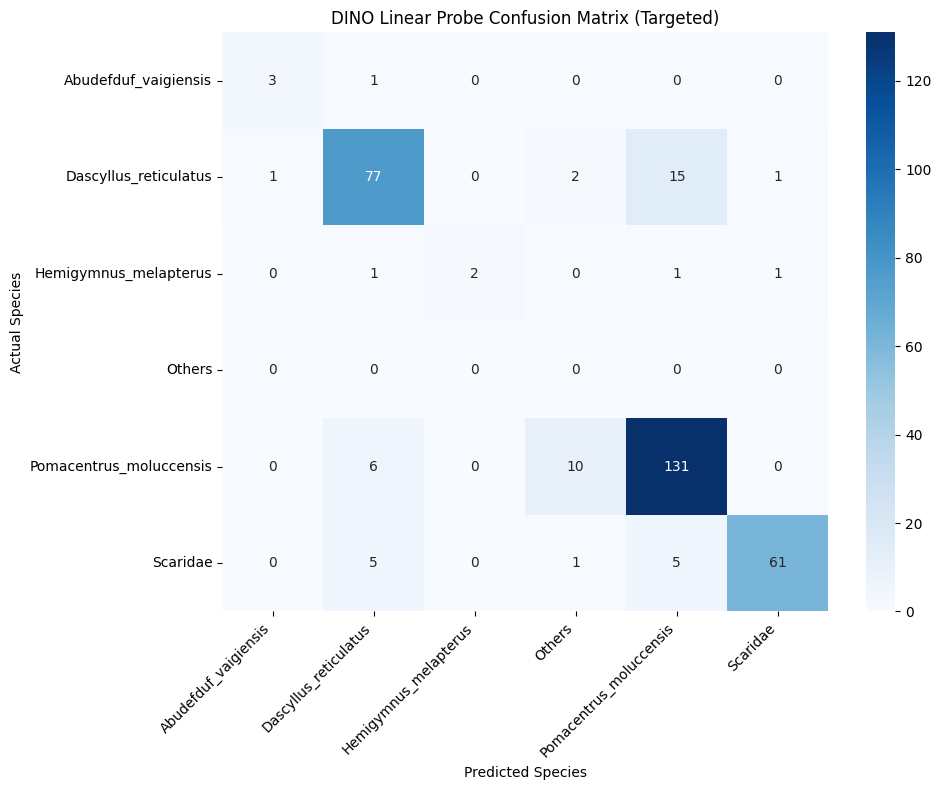

In [ ]:
# 4. Generate Target-Specific Metrics
print("="*50)
print("TARGET SPECIES CLASSIFICATION REPORT (LINEAR PROBE)")
print("="*50)
print(classification_report(y_true, y_pred, zero_division=0))

all_present_classes = sorted(list(set(y_true + y_pred)))

cm = confusion_matrix(y_true, y_pred, labels=all_present_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=all_present_classes, yticklabels=all_present_classes)
plt.title('DINO Linear Probe Confusion Matrix (Targeted)')
plt.xlabel('Predicted Species')
plt.ylabel('Actual Species')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

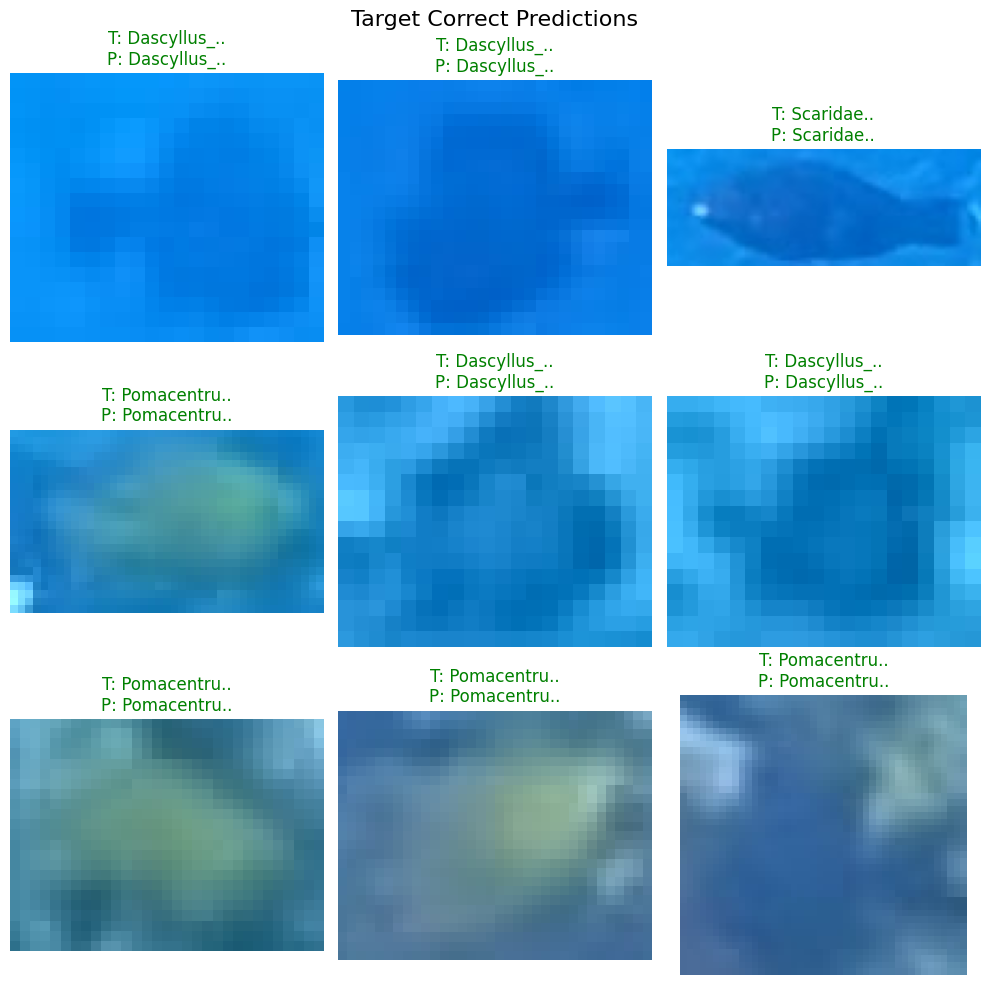

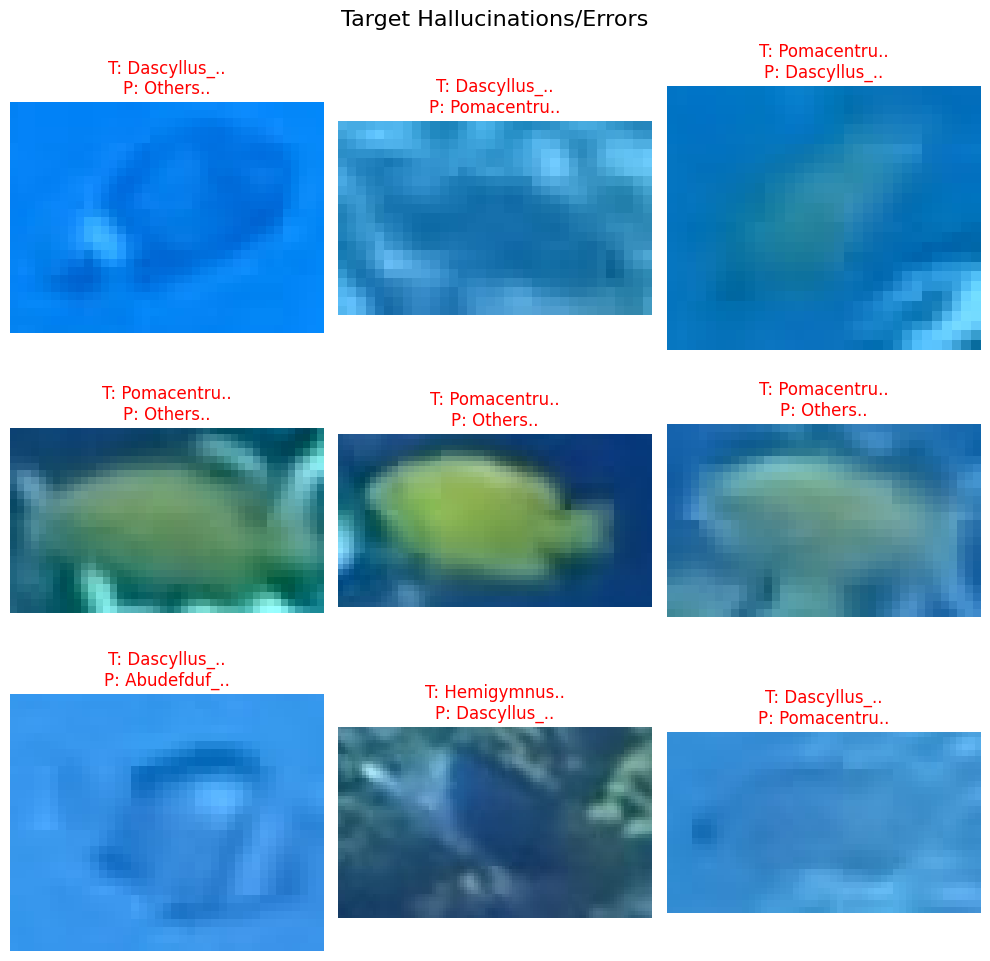

In [ ]:
# 5. Generate Visuals inline
def plot_grid(images_list, title):
    if not images_list: 
        print(f"No images to display for: {title}")
        return
    fig, axes = plt.subplots(3, 3, figsize=(10, 10))
    fig.suptitle(title, fontsize=16)
    for i, ax in enumerate(axes.flat):
        if i < len(images_list):
            crop, t_spec, p_spec = images_list[i]
            ax.imshow(crop)
            ax.set_title(f"T: {t_spec[:10]}..\nP: {p_spec[:10]}..", color='green' if t_spec==p_spec else 'red')
        ax.axis('off')
    plt.tight_layout()
    plt.show()

plot_grid(correct_images, "Target Correct Predictions")
plot_grid(incorrect_images, "Target Hallucinations/Errors")